# Phase 1 — Dataset Exploration & Preparation

**Dataset:** [tmnam20/ViMedAQA](https://huggingface.co/datasets/tmnam20/ViMedAQA) (ACL 2024)  
**Task:** Abstractive Question Answering — Vietnamese Medical Domain  
**Output:**
- `../data/raw/vimedaq_full.json` — full dataset backup
- `../data/processed/train.json`, `val.json`, `test.json` — stratified splits
- `../data/eda/length_distributions.png` — EDA visualizations
- `../data/eda/dataset_stats.csv` — summary statistics

> All paths are relative to `notebooks/` so this notebook runs anywhere without reconfiguration.

## Cell 1 — Install Dependencies

In [1]:
# Install required packages
# Skip if already installed in your environment
import subprocess, sys

packages = [
    "datasets==2.19.0", 
    "pandas==2.2.2", 
    "matplotlib==3.9.0", 
    "seaborn==0.13.2", 
    "scikit-learn",
    "transformers==4.40.0",
    "nltk==3.8.1"
]
for pkg in packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])

print("All packages installed.")

All packages installed.


## Cell 2 — Imports & Path Setup

In [2]:
import json
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from transformers import AutoTokenizer
import nltk

nltk.download('punkt', quiet=True)

NOTEBOOK_DIR = os.path.dirname(os.path.abspath("__file__"))  
DATA_RAW       = os.path.join("..", "data", "raw")
DATA_PROCESSED = os.path.join("..", "data", "processed")
DATA_EDA       = os.path.join("..", "data", "eda")

os.makedirs(DATA_RAW,       exist_ok=True)
os.makedirs(DATA_PROCESSED, exist_ok=True)
os.makedirs(DATA_EDA,       exist_ok=True)

print("Paths configured:")
print(f"  Raw      : {os.path.abspath(DATA_RAW)}")
print(f"  Processed: {os.path.abspath(DATA_PROCESSED)}")
print(f"  EDA      : {os.path.abspath(DATA_EDA)}")

d:\000MINHTHONG\Junior - Semester II\SL\FinalPrjSL\medical\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
The cache for model files in Transformers v4.22.0 has been updated. Migrating your old cache. This is a one-time only operation. You can interrupt this and resume the migration later on by calling `transformers.utils.move_cache()`.
0it [00:00, ?it/s]


Paths configured:
  Raw      : d:\000MINHTHONG\Junior - Semester II\SL\FinalPrjSL\medical\implementation\data\raw
  Processed: d:\000MINHTHONG\Junior - Semester II\SL\FinalPrjSL\medical\implementation\data\processed
  EDA      : d:\000MINHTHONG\Junior - Semester II\SL\FinalPrjSL\medical\implementation\data\eda


## Cell 3 — Load Dataset from HuggingFace

In [3]:
# Load ViMedAQA from HuggingFace Hub
print("Loading tmnam20/ViMedAQA from HuggingFace Hub...")
dataset = load_dataset("tmnam20/ViMedAQA")

print("\nDataset info:")
print(dataset)
print("\nColumn names per split:")
for split in dataset:
    print(f"  {split}: {dataset[split].column_names}")

Loading tmnam20/ViMedAQA from HuggingFace Hub...



Dataset info:
DatasetDict({
    train: Dataset({
        features: ['question_idx', 'question', 'answer', 'context', 'title', 'keyword', 'topic', 'article_url', 'author', 'author_url'],
        num_rows: 39881
    })
    test: Dataset({
        features: ['question_idx', 'question', 'answer', 'context', 'title', 'keyword', 'topic', 'article_url', 'author', 'author_url'],
        num_rows: 2217
    })
    validation: Dataset({
        features: ['question_idx', 'question', 'answer', 'context', 'title', 'keyword', 'topic', 'article_url', 'author', 'author_url'],
        num_rows: 2215
    })
})

Column names per split:
  train: ['question_idx', 'question', 'answer', 'context', 'title', 'keyword', 'topic', 'article_url', 'author', 'author_url']
  test: ['question_idx', 'question', 'answer', 'context', 'title', 'keyword', 'topic', 'article_url', 'author', 'author_url']
  validation: ['question_idx', 'question', 'answer', 'context', 'title', 'keyword', 'topic', 'article_url', 'author', 'au

## Cell 4 — Save Raw Data Backup

In [4]:
# Merge all splits into one list, tag each sample with its original split
all_data = []
for split in dataset:
    for item in dataset[split]:
        record = dict(item)
        record["_original_split"] = split
        all_data.append(record)

raw_path = os.path.join(DATA_RAW, "vimedaq_full.json")
with open(raw_path, "w", encoding="utf-8") as f:
    json.dump(all_data, f, ensure_ascii=False, indent=2)

print(f"Raw data saved: {len(all_data)} total samples -> {os.path.abspath(raw_path)}")

Raw data saved: 44313 total samples -> d:\000MINHTHONG\Junior - Semester II\SL\FinalPrjSL\medical\implementation\data\raw\vimedaq_full.json


## Cell 5 — EDA: Dataset Statistics

In [27]:
# Build a DataFrame for exploratory analysis
df = pd.DataFrame(all_data)
CORE_COLS = ["question", "context", "answer", "topic"]
df = df.dropna(subset=CORE_COLS).reset_index(drop=True)

# EDA-4: Exact Duplicate Detection
initial_count = len(df)
df = df.drop_duplicates(subset=['question', 'context']).reset_index(drop=True)
exact_dup_dropped = initial_count - len(df)

# Create a combined column for overall assessment
df['q_and_c'] = df['question'] + " " + df['context']

# Near-duplicate detection via TF-IDF on combined column
tfidf = TfidfVectorizer(max_features=5000)
tfidf_matrix = tfidf.fit_transform(df['q_and_c'])

# Memory-optimized chunked cosine similarity
CHUNK_SIZE = 1000
near_dup_indices = set()
n_samples = tfidf_matrix.shape[0]

print("Computing cosine similarity in chunks to prevent MemoryError...")
for i in range(0, n_samples, CHUNK_SIZE):
    end_i = min(i + CHUNK_SIZE, n_samples)
    
    # Calculate similarity for the current chunk against ALL other samples
    chunk_sim = cosine_similarity(tfidf_matrix[i:end_i], tfidf_matrix)
    
    # Mask out the lower triangle and diagonal to avoid self-matches and duplicate pairs
    # We only care about relationships where the column index > row index
    for row_idx_in_chunk, full_row_idx in enumerate(range(i, end_i)):
        # Only look at columns (other items) strictly AFTER the current item
        # to ensure we don't flag an item because of a reverse match we already processed
        matches = np.where(chunk_sim[row_idx_in_chunk, full_row_idx + 1:] > 0.95)[0]
        
        # Adjust matches index back to the global scale
        adjusted_matches = matches + (full_row_idx + 1)
        near_dup_indices.update(adjusted_matches)

# Convert set to sorted list for dropping
near_dup_indices_list = sorted(list(near_dup_indices))

# Drop near-duplicates and the temporary column
df_clean = df.drop(index=near_dup_indices_list).reset_index(drop=True)
df_clean = df_clean.drop(columns=['q_and_c'])

print(f"\nEDA-4: Duplication & Leakage Analysis")
print(f"  - Dropped exact duplicates: {exact_dup_dropped}")
print(f"  - Dropped near-duplicates (Q+C similarity > 0.95): {len(near_dup_indices_list)}")
print(f"  - Final clean samples: {len(df_clean)}")

# Word-level length statistics
df_clean["question_len"] = df_clean["question"].apply(lambda x: len(str(x).split()))
df_clean["context_len"]  = df_clean["context"].apply(lambda x: len(str(x).split()))
df_clean["answer_len"]   = df_clean["answer"].apply(lambda x: len(str(x).split()))

print("\nBasic length statistics (word count):")
print(df_clean[["question_len", "context_len", "answer_len"]].describe().round(2))

Computing cosine similarity in chunks to prevent MemoryError...

EDA-4: Duplication & Leakage Analysis
  - Dropped exact duplicates: 2
  - Dropped near-duplicates (Q+C similarity > 0.95): 20758
  - Final clean samples: 23553

Basic length statistics (word count):
       question_len  context_len  answer_len
count      23553.00     23553.00    23553.00
mean          13.86        95.31       23.19
std            5.05        78.83       13.35
min            3.00         0.00        1.00
25%           10.00        42.00       14.00
50%           13.00        71.00       21.00
75%           17.00       126.00       29.00
max           83.00      1197.00      204.00


## Cell 5.1 — EDA-1: Tokenizer Length & EDA-2: Abstractiveness

In [28]:
# EDA-1: Tokenizer-specific Length Analysis
print("Loading Tokenizers for EDA-1...")
tok_vit5 = AutoTokenizer.from_pretrained("VietAI/vit5-base")
tok_bartpho = AutoTokenizer.from_pretrained("vinai/bartpho-word")

df_clean['ctx_vit5_tokens'] = df_clean['context'].apply(lambda x: len(tok_vit5.encode(str(x))))
df_clean['ctx_bartpho_tokens'] = df_clean['context'].apply(lambda x: len(tok_bartpho.encode(str(x))))

print("\nEDA-1: Context Tokenization Lengths:")
print(df_clean[['ctx_vit5_tokens', 'ctx_bartpho_tokens']].describe().round(2))
print("\nTruncation Risk Analysis (Context > 512 tokens):")
print(f"  ViT5    : {(df_clean['ctx_vit5_tokens'] > 512).mean()*100:.2f}%")
print(f"  BARTpho : {(df_clean['ctx_bartpho_tokens'] > 512).mean()*100:.2f}%")

# EDA-2: Abstractiveness Measurement (N-gram overlap)
def calculate_overlap(context, answer):
    c_tokens = set(nltk.word_tokenize(str(context).lower()))
    a_tokens = set(nltk.word_tokenize(str(answer).lower()))
    if not a_tokens: return 0.0
    return len(c_tokens.intersection(a_tokens)) / len(a_tokens)

df_clean['extractive_overlap'] = df_clean.apply(lambda x: calculate_overlap(x['context'], x['answer']), axis=1)

print("\nEDA-2: Abstractiveness Measurement:")
print(f"  Average vocabulary overlap between Answer and Context: {df_clean['extractive_overlap'].mean()*100:.2f}%")
print(f"  (Overlap < 100% indicates abstractive paraphrasing/generation)")

Loading Tokenizers for EDA-1...


d:\000MINHTHONG\Junior - Semester II\SL\FinalPrjSL\medical\.venv\Lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(



EDA-1: Context Tokenization Lengths:
       ctx_vit5_tokens  ctx_bartpho_tokens
count         23553.00            23553.00
mean            115.36              121.96
std              93.19               97.90
min               1.00                2.00
25%              52.00               55.00
50%              88.00               93.00
75%             152.00              161.00
max            1517.00             1523.00

Truncation Risk Analysis (Context > 512 tokens):
  ViT5    : 0.53%
  BARTpho : 0.64%

EDA-2: Abstractiveness Measurement:
  Average vocabulary overlap between Answer and Context: 82.25%
  (Overlap < 100% indicates abstractive paraphrasing/generation)


## Cell 5.2 — EDA-3: Domain Vocabulary & N-gram Analysis

In [29]:
def get_top_ngrams(corpus, n=None, top_k=10):
    vec = CountVectorizer(ngram_range=(n, n)).fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0) 
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)
    return words_freq[:top_k]

print("EDA-3: Top 10 Question Start Bi-grams:")
top_question_bigrams = get_top_ngrams(df_clean['question'], n=2, top_k=10)
for word, freq in top_question_bigrams:
    print(f"  - '{word}': {freq}")

print("\nEDA-3: Top 10 Context Tri-grams:")
top_context_trigrams = get_top_ngrams(df_clean['context'], n=3, top_k=10)
for word, freq in top_context_trigrams:
    print(f"  - '{word}': {freq}")

EDA-3: Top 10 Question Start Bi-grams:
  - 'sử dụng': 3545
  - 'có thể': 3299
  - 'thế nào': 3149
  - 'như thế': 2590
  - 'là gì': 2565
  - 'tác dụng': 1980
  - 'điều trị': 1801
  - 'trường hợp': 1255
  - 'có tác': 1101
  - 'bao nhiêu': 1055

EDA-3: Top 10 Context Tri-grams:
  - 'các triệu chứng': 2227
  - 'có tác dụng': 2167
  - 'có thể gây': 1850
  - 'sử dụng thuốc': 1615
  - 'được sử dụng': 1421
  - 'khi sử dụng': 1366
  - 'cũng có thể': 1169
  - 'có thể làm': 1152
  - 'có thể được': 1053
  - 'tác dụng phụ': 1047


## Cell 6 — EDA: Visualizations

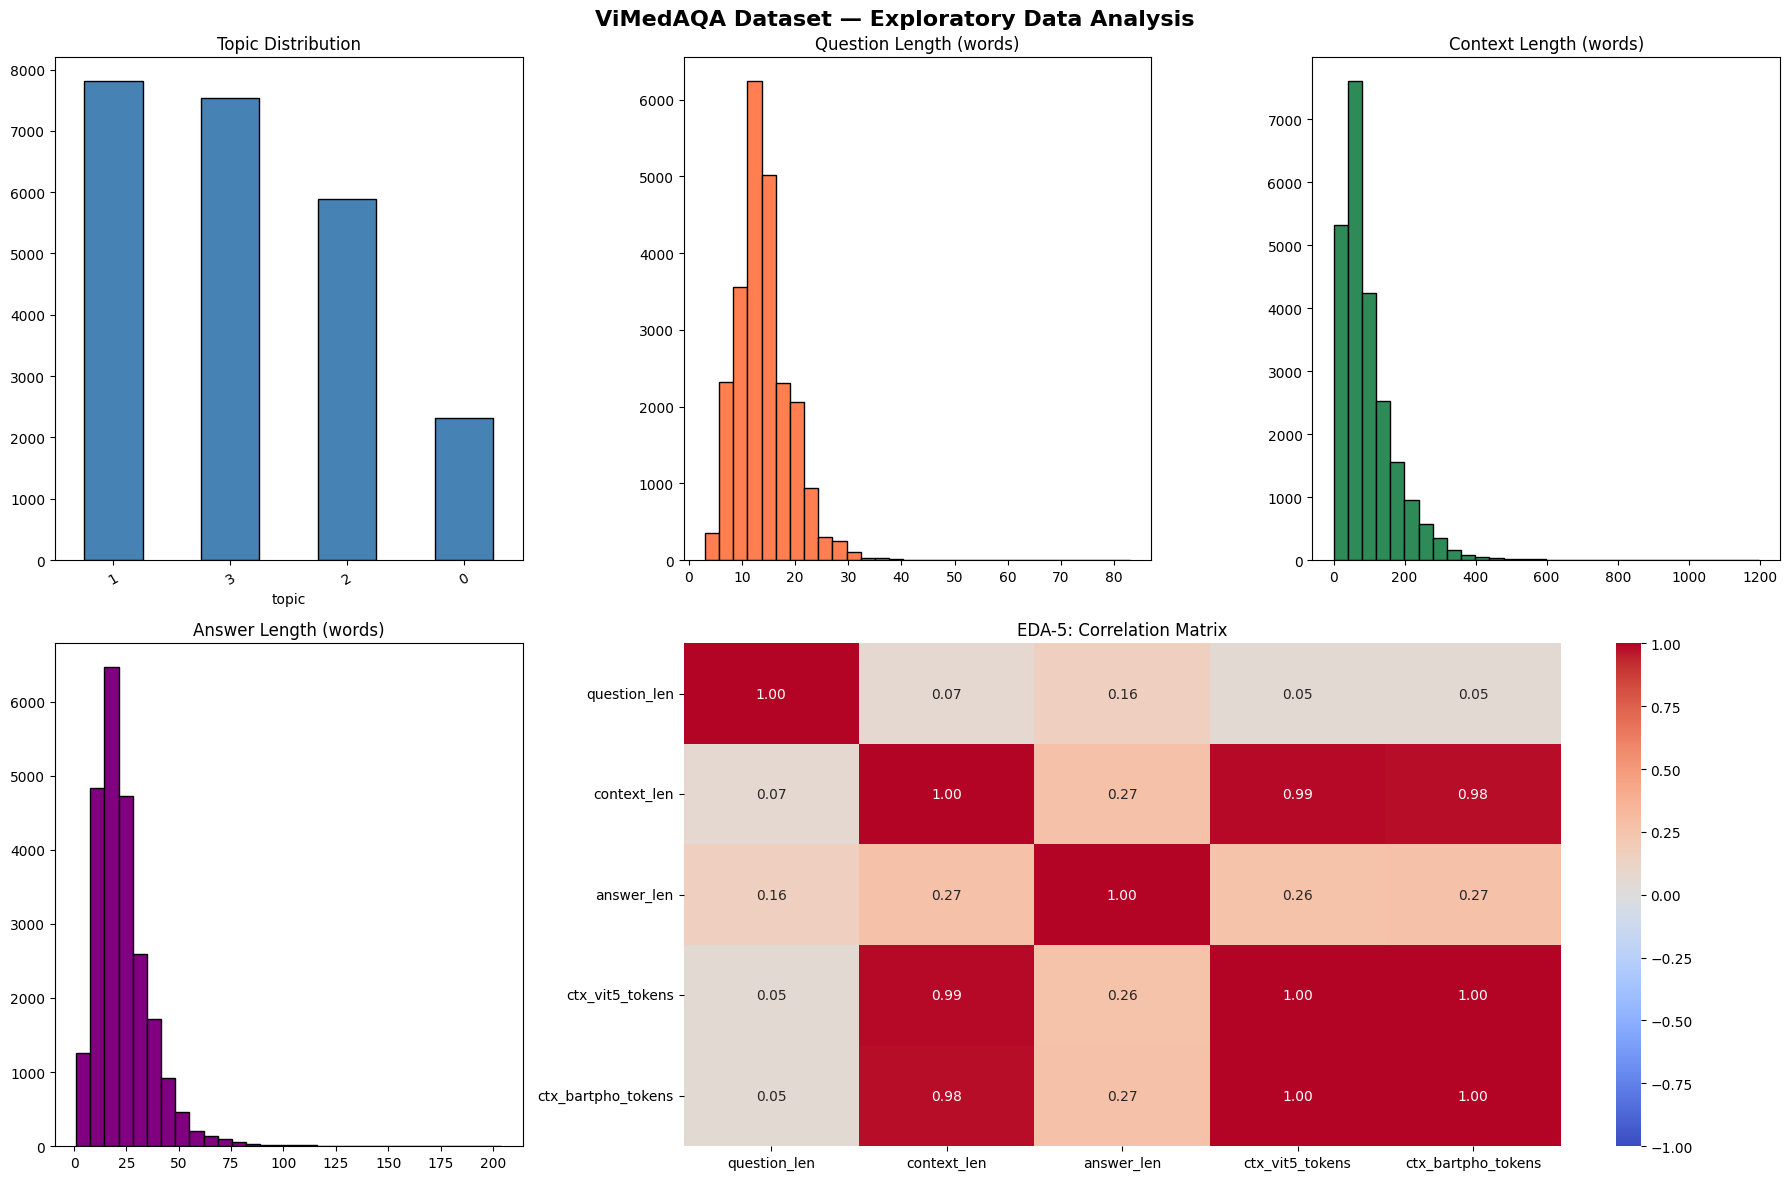

EDA chart saved -> d:\000MINHTHONG\Junior - Semester II\SL\FinalPrjSL\medical\implementation\data\eda\comprehensive_eda.png


In [30]:
fig = plt.figure(figsize=(18, 12))
fig.suptitle("ViMedAQA Dataset — Exploratory Data Analysis", fontsize=16, fontweight="bold")

ax1 = plt.subplot(2, 3, 1)
topic_counts = df_clean["topic"].value_counts()
topic_counts.plot(kind="bar", ax=ax1, color="steelblue", edgecolor="black")
ax1.set_title("Topic Distribution")
ax1.tick_params(axis="x", rotation=30)

ax2 = plt.subplot(2, 3, 2)
ax2.hist(df_clean["question_len"], bins=30, color="coral", edgecolor="black")
ax2.set_title("Question Length (words)")

ax3 = plt.subplot(2, 3, 3)
ax3.hist(df_clean["context_len"], bins=30, color="seagreen", edgecolor="black")
ax3.set_title("Context Length (words)")

ax4 = plt.subplot(2, 3, 4)
ax4.hist(df_clean["answer_len"], bins=30, color="purple", edgecolor="black")
ax4.set_title("Answer Length (words)")

# EDA-5: Cross-Variable Correlation Matrix
ax5 = plt.subplot(2, 3, (5, 6))
corr_cols = ['question_len', 'context_len', 'answer_len', 'ctx_vit5_tokens', 'ctx_bartpho_tokens']
corr_matrix = df_clean[corr_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", ax=ax5, vmin=-1, vmax=1)
ax5.set_title("EDA-5: Correlation Matrix")

plt.tight_layout()

eda_png = os.path.join(DATA_EDA, "comprehensive_eda.png")
plt.savefig(eda_png, dpi=150, bbox_inches="tight")
plt.show()
print(f"EDA chart saved -> {os.path.abspath(eda_png)}")

## Cell 7 — Stratified Train / Val / Test Split

In [36]:
# Stratified split: 80% train / 10% val / 10% test
train_df, temp_df = train_test_split(
    df_clean,
    test_size=0.2,
    random_state=42,
    stratify=df_clean["topic"],
)
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    random_state=42,
    stratify=temp_df["topic"],
)

print(f"\nSplit sizes:")
print(f"  Train : {len(train_df)} ({len(train_df)/len(df_clean)*100:.1f}%)")
print(f"  Val   : {len(val_df)} ({len(val_df)/len(df_clean)*100:.1f}%)")
print(f"  Test  : {len(test_df)} ({len(test_df)/len(df_clean)*100:.1f}%)")


Split sizes:
  Train : 18842 (80.0%)
  Val   : 2355 (10.0%)
  Test  : 2356 (10.0%)


## Cell 7.1 — Sanity Check: Data Leakage Analysis

In [41]:
# %% [markdown]
# ## Cell 7.1 — Sanity Check: Data Leakage Analysis (Question + Context)

# %%
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

print("Running Sanity Check: Cross-checking Test (Q+C) against Train (Q+C)...")

# 1. Tạo chuỗi gộp (Câu hỏi + Ngữ cảnh) cho cả hai tập
train_qc = train_df['question'] + " " + train_df['context']
test_qc  = test_df['question'] + " " + test_df['context']

# 2. Huấn luyện TF-IDF trên toàn bộ dữ liệu gộp để đồng bộ từ vựng
tfidf = TfidfVectorizer(max_features=5000)
tfidf.fit(pd.concat([train_qc, test_qc]))

train_tfidf = tfidf.transform(train_qc)
test_tfidf  = tfidf.transform(test_qc)

# 3. Tính toán độ tương đồng theo lô (chunk) để tránh MemoryError
CHUNK_SIZE = 500
leaked_test_indices = set()
n_test_samples = test_tfidf.shape[0]

for i in range(0, n_test_samples, CHUNK_SIZE):
    end_i = min(i + CHUNK_SIZE, n_test_samples)
    
    # So sánh lô Test (Q+C) hiện tại với toàn bộ Train (Q+C)
    chunk_sim = cosine_similarity(test_tfidf[i:end_i], train_tfidf)
    
    # Lọc các mẫu Test có độ tương đồng Q+C > 0.95 với bất kỳ mẫu Train nào
    for row_idx_in_chunk in range(chunk_sim.shape[0]):
        if np.max(chunk_sim[row_idx_in_chunk]) > 0.95:
            leaked_test_indices.add(i + row_idx_in_chunk)

# 4. Báo cáo kết quả
leakage_rate = len(leaked_test_indices) / n_test_samples * 100
print(f"Total Test samples: {n_test_samples}")
print(f"Leaked Test samples (Q+C similarity > 0.95 with Train): {len(leaked_test_indices)}")
print(f"Data Leakage Rate: {leakage_rate:.2f}%\n")

if leakage_rate > 0:
    print("[WARNING] Data leakage detected! Tập Test chứa các cặp Câu hỏi-Ngữ cảnh đã xuất hiện trong tập Train.")
    print("Khuyến nghị: Xem xét loại bỏ các mẫu bị rò rỉ này khỏi `test_df` trước khi chuyển sang Cell 8, hoặc phải ghi chú rõ ràng vào báo cáo (Phase 8).")
else:
    print("[OK] Không phát hiện rò rỉ dữ liệu (Q+C) giữa tập Train và Test. Dữ liệu an toàn để đánh giá.")

Running Sanity Check: Cross-checking Test (Q+C) against Train (Q+C)...
Total Test samples: 2356
Leaked Test samples (Q+C similarity > 0.95 with Train): 17
Data Leakage Rate: 0.72%

[WARNING] Data leakage detected! Tập Test chứa các cặp Câu hỏi-Ngữ cảnh đã xuất hiện trong tập Train.
Khuyến nghị: Xem xét loại bỏ các mẫu bị rò rỉ này khỏi `test_df` trước khi chuyển sang Cell 8, hoặc phải ghi chú rõ ràng vào báo cáo (Phase 8).


## Cell 8 — Save Splits to processed/

In [42]:
# Keep only the columns used by downstream training notebooks
KEEP_COLS = ["question", "context", "answer", "topic"]

split_map = {
    "train": train_df,
    "val":   val_df,
    "test":  test_df,
}

for name, split_df in split_map.items():
    out_path = os.path.join(DATA_PROCESSED, f"{name}.json")
    split_df[KEEP_COLS].to_json(
        out_path,
        orient="records",
        force_ascii=False,
        indent=2,
    )
    print(f"Saved {name}.json ({len(split_df)} samples) -> {os.path.abspath(out_path)}")

print("\nAll splits saved successfully.")

Saved train.json (18842 samples) -> d:\000MINHTHONG\Junior - Semester II\SL\FinalPrjSL\medical\implementation\data\processed\train.json
Saved val.json (2355 samples) -> d:\000MINHTHONG\Junior - Semester II\SL\FinalPrjSL\medical\implementation\data\processed\val.json
Saved test.json (2356 samples) -> d:\000MINHTHONG\Junior - Semester II\SL\FinalPrjSL\medical\implementation\data\processed\test.json

All splits saved successfully.


## Cell 9 — Save Summary Statistics CSV

In [43]:
stats = {
    "total_samples":    len(df_clean),
    "train_size":       len(train_df),
    "val_size":         len(val_df),
    "test_size":        len(test_df),
    "num_topics":       df_clean["topic"].nunique(),
    "avg_extractive_overlap": round(df_clean["extractive_overlap"].mean(), 4),
    "avg_ctx_vit5_tokens": round(df_clean["ctx_vit5_tokens"].mean(), 2),
    "max_ctx_vit5_tokens": int(df_clean["ctx_vit5_tokens"].max()),
    "avg_ctx_bartpho_tokens": round(df_clean["ctx_bartpho_tokens"].mean(), 2),
    "max_ctx_bartpho_tokens": int(df_clean["ctx_bartpho_tokens"].max()),
}

stats_path = os.path.join(DATA_EDA, "dataset_stats.csv")
pd.DataFrame([stats]).to_csv(stats_path, index=False)

print("Comprehensive Summary statistics saved.")

Comprehensive Summary statistics saved.


## Cell 10 — Phase 1 Checklist Verification

In [44]:
# Verify all expected output files exist and are non-empty
expected_files = [
    os.path.join(DATA_RAW,       "vimedaq_full.json"),
    os.path.join(DATA_PROCESSED, "train.json"),
    os.path.join(DATA_PROCESSED, "val.json"),
    os.path.join(DATA_PROCESSED, "test.json"),
    os.path.join(DATA_EDA,       "length_distributions.png"),
    os.path.join(DATA_EDA,       "dataset_stats.csv"),
]

print("Phase 1 Output Verification:")
all_ok = True
for fp in expected_files:
    abs_fp = os.path.abspath(fp)
    exists = os.path.isfile(abs_fp)
    size   = os.path.getsize(abs_fp) if exists else 0
    status = "OK" if (exists and size > 0) else "MISSING"
    if status != "OK":
        all_ok = False
    print(f"  [{status}] {os.path.basename(abs_fp)} ({size:,} bytes)")

if all_ok:
    print("\nAll Phase 1 outputs verified. Ready for Phase 2 (Groq baseline).")
else:
    print("\nSome outputs are missing. Re-run the cells above.")

Phase 1 Output Verification:
  [OK] vimedaq_full.json (61,879,169 bytes)
  [OK] train.json (16,476,206 bytes)
  [OK] val.json (2,023,942 bytes)
  [OK] test.json (2,057,119 bytes)
  [OK] length_distributions.png (127,670 bytes)
  [OK] dataset_stats.csv (221 bytes)

All Phase 1 outputs verified. Ready for Phase 2 (Groq baseline).
